In [73]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_201112
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
from draw_graph import Scatter
from matplotlib.backends.backend_pdf import PdfPages

In [74]:
file_path = glob.glob('./control/2009??_IRheating_lin22.6_100mW_5000ms_26/nuc/*.csv')
file_path.sort()

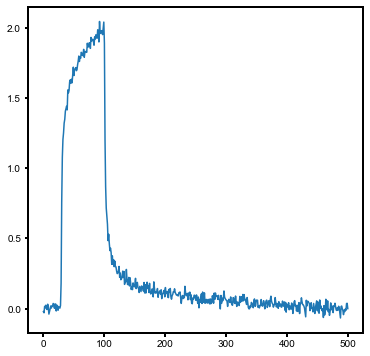

In [75]:
#t=0で切り取る
plt.figure(figsize = (6, 6))
result_nuc = 0
data_set_nuc = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    lifetime = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+400]
    result_nuc += lifetime
    data_set_nuc = pd.concat([data_set_nuc, pd.DataFrame(lifetime)], axis = 1)
    
result_nuc = result_nuc/len(file_path)
result_nuc = result_nuc - np.mean(result_nuc[:10])
result_nuc = result_nuc
plt.plot(result_nuc)
plt.show()

In [76]:
file_path = glob.glob('./ActD/20112*_relaxation_100mW_ActD/*.csv')
file_path.sort()

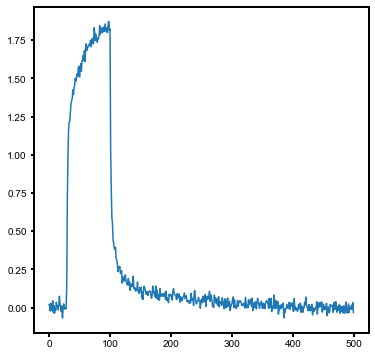

In [77]:
#t=0で切り取る
plt.figure(figsize = (6, 6))
result_ActD = 0
data_set_ActD = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    lifetime = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+400]
    result_ActD += lifetime
    data_set_ActD = pd.concat([data_set_ActD, pd.DataFrame(lifetime)], axis = 1)
    
result_ActD = result_ActD/len(file_path)
result_ActD = result_ActD - np.mean(result_ActD[:10])
result_ActD = result_ActD
plt.plot(result_ActD)
plt.show()

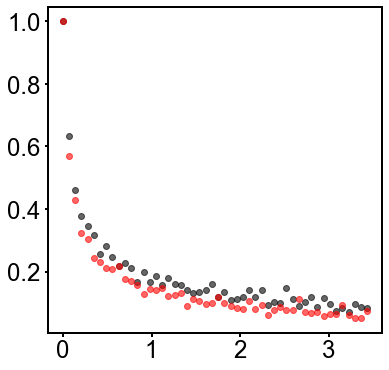

In [78]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(labelsize=24)
result_nuc_cut = result_nuc[100:150]
result_ActD_cut = result_ActD[100:150]
time = [i*0.07 for i in range(len(result_nuc_cut))]
plt.plot(time, result_nuc_cut/max(result_nuc_cut), alpha = 0.6, color = 'black', marker = 'o', linewidth = 0)
plt.plot(time, result_ActD_cut/max(result_ActD_cut), alpha = 0.6, color = 'red', marker = 'o', linewidth = 0)
plt.show()

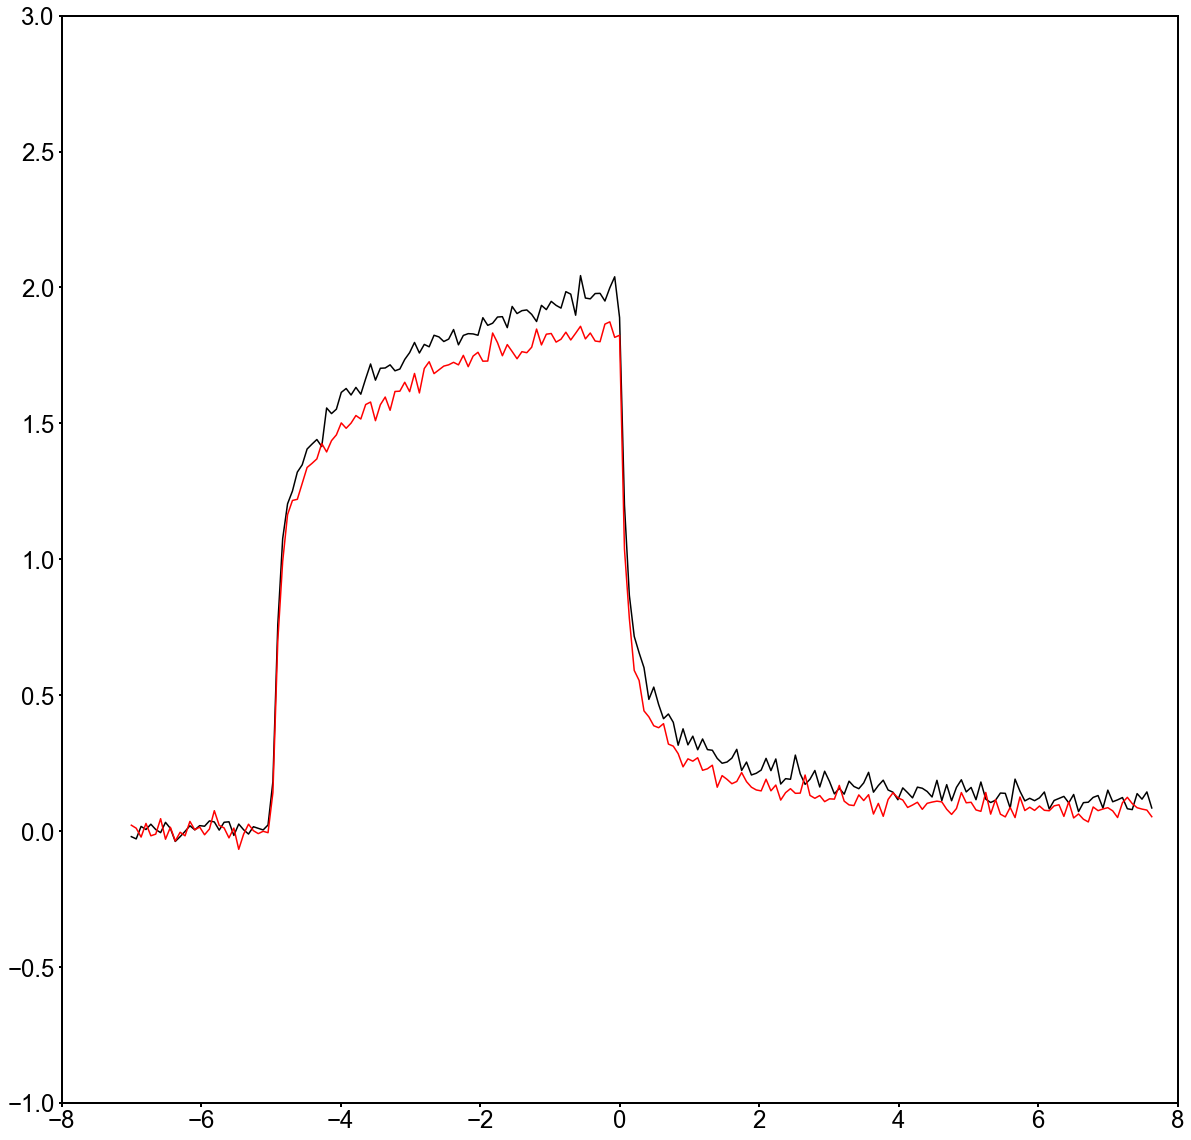

In [79]:
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(labelsize=24)
time = [0.07*(i-100) for i in range(len(result_ActD))]
plt.plot(time[0:210], result_nuc[0:210], color = 'black')
plt.plot(time[0:210], result_ActD[0:210], color = 'red')
plt.xlim(-8, 8)
plt.ylim(-1, 3)
plt.show()

pp = PdfPages('./FigS14.pdf')
pp.savefig(fig)
pp.close()


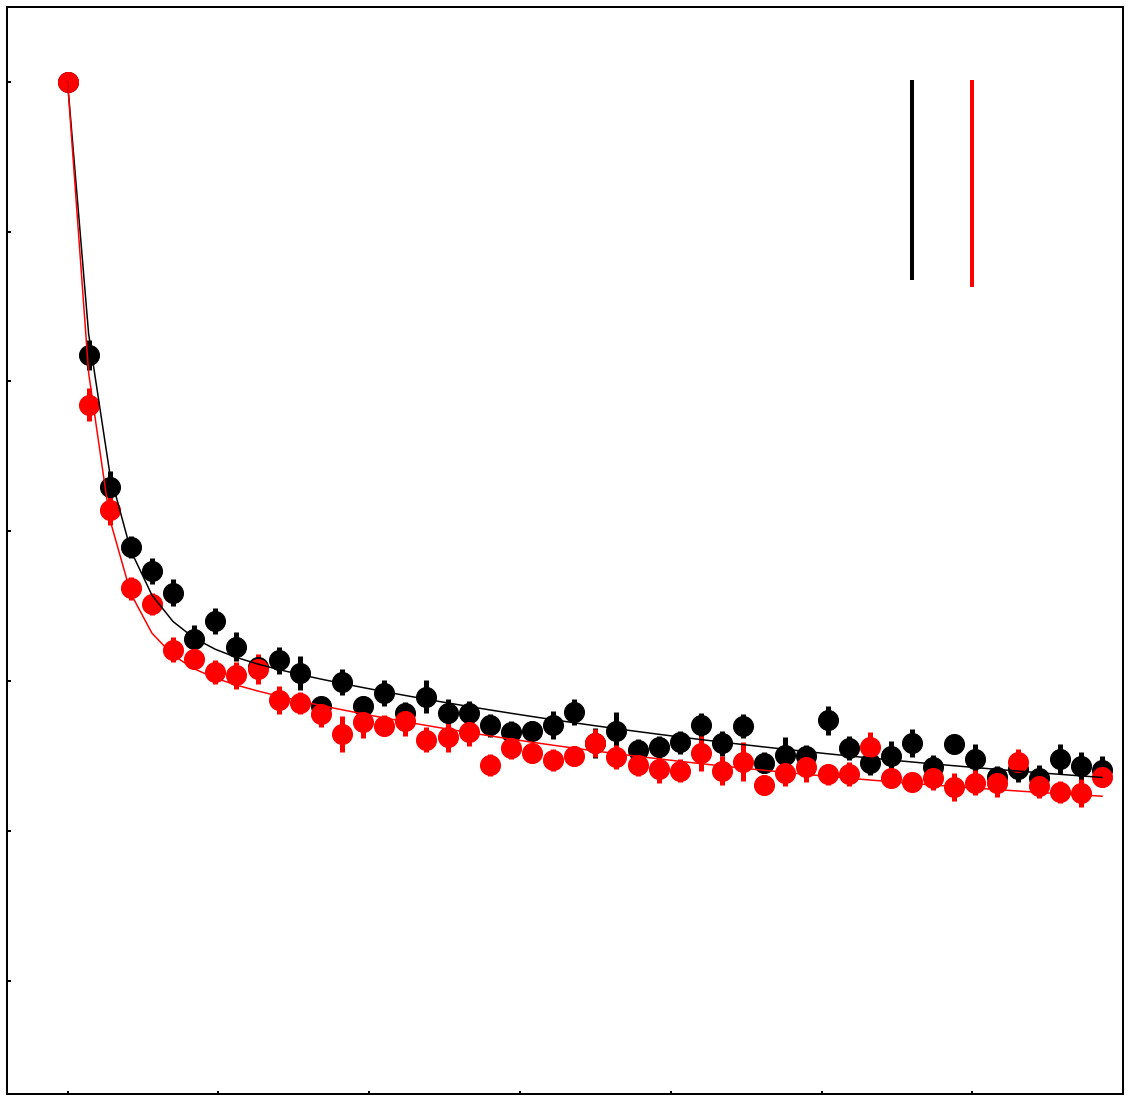

In [80]:
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time_ActD = [(i)*0.07 for i in range(len(result_ActD_cut))]
time_nuc = [(i)*0.07 for i in range(len(result_nuc_cut))]

#1˚Cを示すバーを挿入
ActD_bar = [100- 50/max(result_ActD_cut)*i/100 for i in range(100)]
ActD_bar_pos = [3.0 for i in range(len(ActD_bar))]
plt.plot(ActD_bar_pos, ActD_bar, linewidth = 4, color = 'red', linestyle = '-')

#1˚Cを示すバーを挿入
nuc_bar = [100- 50/max(result_nuc_cut)*i/100 for i in range(100)]
nuc_bar_pos = [2.8 for i in range(len(nuc_bar))]
plt.plot(nuc_bar_pos, nuc_bar, linewidth = 4, color = 'black', linestyle = '-')


plt.tick_params(labelbottom=False,
                labelleft=False,
                labelright=False,
                labeltop=False)


#SEMを計算
data_set_nuc = data_set_nuc - np.mean(data_set_nuc.iloc[:10, :])
data_set_nuc = data_set_nuc/data_set_nuc.iloc[100, :]*100
sem_nuc = data_set_nuc.sem(axis = 1)
sem_nuc[0] = 0

data_set_ActD = data_set_ActD - np.mean(data_set_ActD.iloc[:10, :])
data_set_ActD = data_set_ActD/data_set_ActD.iloc[100, :]*100
sem_ActD = data_set_ActD.sem(axis = 1)
sem_ActD[0] = 0

result_ActD_cut = result_ActD_cut/result_ActD_cut[0]
result_nuc_cut = result_nuc_cut/result_nuc_cut[0]
plt.errorbar(time_nuc, result_nuc_cut*100, yerr = np.ravel(sem_nuc)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time_ActD, result_ActD_cut*100, yerr = np.ravel(sem_ActD)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_nuc, result_nuc_cut*100, color = 'black', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time_ActD, result_ActD_cut*100, color = 'red', markersize = 20, marker = 'o', linewidth = 0)
plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)
#plt.xlabel('Time (sec)', fontsize = 24)
#plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)

#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_ActD = curve_fit(relaxation, time_ActD, result_ActD_cut)[0]
result_nuc = curve_fit(relaxation, time_nuc, result_nuc_cut)[0]

#fitting結果の図示
plt.plot(time_nuc, relaxation(np.ravel(time_nuc), result_nuc[0], result_nuc[1], result_nuc[2])*100, color = 'black')
plt.plot(time_ActD, relaxation(np.ravel(time_ActD), result_ActD[0], result_ActD[1], result_ActD[2])*100, color = 'red')

#pdfのセーブ
pp = PdfPages('./FigS14_relaxation.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(result_ActD_cut*100).to_csv('normed_ActD.csv')
pd.DataFrame(result_nuc_cut*100).to_csv('normed_nuc.csv')
(sem_ActD)[100:150].to_csv('sem_ActD.csv')
(sem_nuc)[100:150].to_csv('sem_nuc.csv')

In [81]:
#welchのt検定
sum_ActD = data_set_ActD.iloc[102:150].sum().values
sum_nuc = data_set_nuc.iloc[102:150].sum().values
sp.stats.ttest_ind(sum_ActD, sum_nuc, equal_var = False)

Ttest_indResult(statistic=-2.940354357380658, pvalue=0.004856298805055674)

In [82]:
sem_ActD_bar = (sum_ActD*0.07).std(ddof = 1)/np.sqrt(len(sum_ActD))
sem_nuc_bar = (sum_nuc*0.07).std(ddof = 1)/np.sqrt(len(sum_nuc))

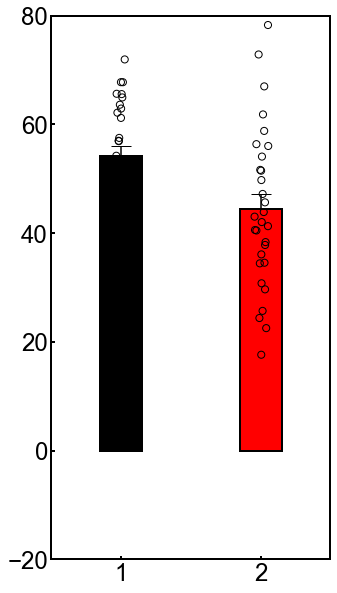

In [83]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_ActD_ave = np.average(sum_ActD*0.07)
sum_nuc_ave = np.average(sum_nuc*0.07)
plt.bar(2, sum_ActD_ave, yerr = [[0], [sem_ActD_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_ActD)) 
plt.scatter(x, sum_ActD*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.bar(1, sum_nuc_ave, yerr = [[0], [sem_nuc_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_nuc)) 
plt.scatter(x, sum_nuc*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)


plt.ylim(-20, 80)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./FigS14_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_ActD*0.07).to_csv('AUC_ActD.csv')
pd.DataFrame(sum_nuc*0.07).to_csv('AUC_nuc.csv')

In [84]:
print(sum_ActD_ave)
print(sum_nuc_ave)

44.476353
54.18754


In [85]:
print(sem_ActD_bar)
print(sem_nuc_bar)

2.676940963977904
1.9344259566848518
